In [11]:
pip install face_recognition numpy scikit-learn matplotlib

In [24]:
"""
DSTS Implementation - Multi-Building Surveillance System
Based on: Mohan & Menon, "Modelling large scale camera networks for
identification and tracking: an abstract framework", IET Computer Vision 2020
"""

import face_recognition
import numpy as np
from sklearn.datasets import fetch_lfw_people
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional
from datetime import datetime, timedelta
import math
import copy

# ============================================================================
# CONSTANTS (Based on Paper Requirements)
# ============================================================================

# Paper Section 4: "Our face data set contains 40 images of each of the 35
# registered occupants"
IMAGES_PER_PERSON = 30

# Paper Section 4: "minimum number of 'TRUE' votes that such genuine matches
# obtained was observed to be 12"
MIN_VOTE_THRESHOLD = 12

# Tolerance for face matching (standard face_recognition default)
FACE_MATCH_TOLERANCE = 0.6

# Distance to probability mapping constant
# README states: "p = exp(-5.0 × d)"
DISTANCE_DECAY_FACTOR = 5.0

# Number of buildings and occupants per building
# Your requirement: 5 buildings with 5 occupants each = 25 total
NUM_BUILDINGS = 5
OCCUPANTS_PER_BUILDING = 5
TOTAL_OCCUPANTS = NUM_BUILDINGS * OCCUPANTS_PER_BUILDING

# Probability constraint tolerance (Equation 6 verification)
# Paper Eq. 6: ∑ p_jk^u(o_i^u) + p_Tk^u(o_i^u) = 1.0
PROBABILITY_SUM_TOLERANCE = 1e-6

# Zone definitions for each building
# Building zones: entry, intermediate zones, exit, transition zone
# Example: Building 1 has z1 (entry), z2, z3 (intermediate), z4 (exit), zT (transition)
BUILDING_ZONE_CONFIGS = {
    0: ['z1_b0', 'z2_b0', 'z3_b0', 'z4_b0', 'zT_b0'],  # 5 zones total
    1: ['z1_b1', 'z2_b1', 'z3_b1', 'z4_b1', 'zT_b1'],
    2: ['z1_b2', 'z2_b2', 'z3_b2', 'z4_b2', 'zT_b2'],
    3: ['z1_b3', 'z2_b3', 'z3_b3', 'z4_b3', 'zT_b3'],
    4: ['z1_b4', 'z2_b4', 'z3_b4', 'z4_b4', 'zT_b4'],
}

In [25]:
# ============================================================================
# DATA STRUCTURES (Paper Section 3.1 - Definitions)
# ============================================================================

@dataclass
class OccupantEntry:
    """
    Represents one row in a state table (Table 1 or Table 2 from paper)

    Paper Definition (Eq. 2):
    Z_jk^u = {⟨o_i^u, p_jk^u(o_i^u)⟩ | 1 ≤ i ≤ n_u^R} ∪
             {⟨o_i'^u', p_jk^u(o_i'^u')⟩ | 1 ≤ i' ≤ n_u^V}

    Each occupant has a probability distribution across all zones in a building.
    """
    occupant_id: str  # Unique identifier for the occupant
    probs: Dict[str, float]  # zone_id → probability of presence

    def verify_constraint(self) -> bool:
        """
        Verify Equation 6 from paper:
        ∑_{j=1}^{m_u} p_jk^u(o_i^u) + p_Tk^u(o_i^u) = 1.0

        The sum of probabilities across all zones (including transition zone)
        must equal 1.0 for each occupant.

        Returns:
            True if constraint is satisfied within tolerance
        """
        total = sum(self.probs.values())
        is_valid = abs(total - 1.0) < PROBABILITY_SUM_TOLERANCE

        if not is_valid:
            print(f"WARNING: Constraint violation for {self.occupant_id}: "
                  f"sum = {total:.10f}")

        return is_valid

    def renormalize(self) -> None:
        """
        Renormalize probabilities to sum to 1.0
        Needed to guard against floating-point drift after many updates
        """
        total = sum(self.probs.values())
        if total > 0:
            self.probs = {zone: prob / total for zone, prob in self.probs.items()}


@dataclass
class StateTable:
    """
    Represents either a Registered State Table (Table 1) or Visitor State Table (Table 2)

    Paper Section 3.2:
    - Registered Table (s_R^u): Fixed rows for building's registered occupants
    - Visitor Table (s_V^u): Dynamic rows for occupants from other buildings (roaming)

    State s_ku^u = s_R_ku^u ∪ s_V_ku^u (Equation 3)
    """
    entries: Dict[str, OccupantEntry] = field(default_factory=dict)

    def add_occupant(self, occupant_id: str, zones: List[str],
                     initial_zone: Optional[str] = None) -> None:
        """
        Add an occupant to the state table

        Args:
            occupant_id: Unique identifier
            zones: List of all zones in the building
            initial_zone: If specified, start with high probability here;
                         otherwise uniform distribution
        """
        if initial_zone and initial_zone in zones:
            # Start with high probability in initial zone
            probs = {zone: 0.01 for zone in zones}
            probs[initial_zone] = 1.0 - 0.01 * (len(zones) - 1)
        else:
            # Uniform distribution (no information about location)
            prob_per_zone = 1.0 / len(zones)
            probs = {zone: prob_per_zone for zone in zones}

        entry = OccupantEntry(occupant_id=occupant_id, probs=probs)
        entry.verify_constraint()  # Verify Eq. 6
        self.entries[occupant_id] = entry

    def get_occupant(self, occupant_id: str) -> Optional[OccupantEntry]:
        """Retrieve occupant's probability distribution"""
        return self.entries.get(occupant_id)

    def remove_occupant(self, occupant_id: str) -> None:
        """Remove occupant from table (e.g., when visitor leaves)"""
        if occupant_id in self.entries:
            del self.entries[occupant_id]

    def get_all_occupants(self) -> List[str]:
        """Get list of all occupant IDs in this table"""
        return list(self.entries.keys())


@dataclass
class RecognitionEvent:
    """
    Represents a recognition event as defined in paper Section 3.1

    Paper Definition:
    e_k^u = ⟨t, z_j^u, P_k⟩

    where:
    - t: timestamp (physical time)
    - z_j^u: zone where recognition occurred
    - P_k = {⟨o_i^u, p_jk^u(o_i^u)⟩ : 1 ≤ i ≤ n_u}: probability distribution
           over all occupants
    """
    timestamp: datetime  # Physical time when event occurred
    building_id: int  # Which building (0-4)
    zone_id: str  # Which zone within the building
    event_counter: int  # Sequence number within the building (k in e_k^u)
    probabilities: Dict[str, float]  # occupant_id → recognition probability
    matched_occupant: str  # Occupant with highest probability
    is_visitor: bool  # True if matched occupant is from another building

    def __repr__(self) -> str:
        return (f"Event(t={self.timestamp.strftime('%H:%M:%S')}, "
                f"b{self.building_id}:{self.zone_id}, "
                f"{self.matched_occupant}, "
                f"p={self.probabilities.get(self.matched_occupant, 0.0):.3f}, "
                f"visitor={self.is_visitor})")

In [26]:
# ============================================================================
# BUILDING-SPECIFIC STATE TRANSITION SYSTEM (BSTS)
# Paper Section 3.1 - Definition of BSTS_u
# ============================================================================

class BSTS:
    """
    Building-Specific State Transition System

    Paper Definition:
    BSTS_u = ⟨S^u, E^u, Δ^u⟩

    where:
    - S^u: set of building-specific states
    - E^u: set of building-specific events
    - Δ^u: S^u × E^u → S^u: transition function

    Each building maintains:
    1. Registered State Table (s_R^u) - for occupants registered to this building
    2. Visitor State Table (s_V^u) - for occupants from other buildings
    """

    def __init__(self, building_id: int, zones: List[str],
                 registered_occupants: List[str]):
        """
        Initialize a Building-Specific State Transition System

        Args:
            building_id: Unique building identifier (0-4)
            zones: List of zone IDs including transition zone (last zone is zT)
            registered_occupants: List of occupant IDs registered to this building
        """
        self.building_id = building_id
        self.zones = zones  # Includes transition zone zT
        self.num_zones = len(zones)

        # Paper Section 3.2: Each building has registered occupants (O_u^R)
        self.registered_occupants = set(registered_occupants)

        # State tables (Paper Eq. 3: s_ku^u = s_R_ku^u ∪ s_V_ku^u)
        self.registered_table = StateTable()
        self.visitor_table = StateTable()

        # Initialize registered occupants with uniform distribution
        # (no prior knowledge of their locations)
        for occupant_id in registered_occupants:
            self.registered_table.add_occupant(occupant_id, zones)

        # Event counter for this building (k in e_k^u)
        self.event_counter = 0

        # Event history for this building (E^u)
        self.event_history: List[RecognitionEvent] = []

        # Current state number
        self.state_counter = 0

    def is_registered(self, occupant_id: str) -> bool:
        """Check if occupant is registered to this building"""
        return occupant_id in self.registered_occupants

    def is_visitor(self, occupant_id: str) -> bool:
        """Check if occupant is currently in visitor table"""
        return occupant_id in self.visitor_table.entries

    def get_occupant_entry(self, occupant_id: str) -> Optional[OccupantEntry]:
        """
        Get occupant's current state (probability distribution)
        Checks registered table first, then visitor table
        """
        entry = self.registered_table.get_occupant(occupant_id)
        if entry is None:
            entry = self.visitor_table.get_occupant(occupant_id)
        return entry

    def apply_transition(self, event: RecognitionEvent) -> None:
        """
        Apply state transition function Δ^u (Paper Eq. 8)

        Implements Equations 9 and 10:
        - Eq. 9 (detected zone j): Z_jk^u = p + (1-p) × Z_{j,k-1}^u
        - Eq. 10 (other zones l≠j): Z_lk^u = (1-p) × Z_{l,k-1}^u

        Args:
            event: Recognition event containing matched occupant and probabilities
        """
        occupant_id = event.matched_occupant
        detected_zone = event.zone_id
        recognition_prob = event.probabilities[occupant_id]

        # Determine which table to update
        if self.is_registered(occupant_id):
            table = self.registered_table
        elif self.is_visitor(occupant_id):
            table = self.visitor_table
        else:
            # New visitor - add to visitor table
            table = self.visitor_table
            table.add_occupant(occupant_id, self.zones)

        # Get current state (s_{k-1}^u)
        entry = table.get_occupant(occupant_id)
        if entry is None:
            print(f"ERROR: Could not find entry for {occupant_id}")
            return

        current_probs = copy.deepcopy(entry.probs)

        # Apply transition function
        x_i = 1.0 - recognition_prob  # Complement probability
        new_probs = {}

        for zone in self.zones:
            if zone == detected_zone:
                # Equation 9: detected zone gets boosted
                new_probs[zone] = recognition_prob + x_i * current_probs[zone]
            else:
                # Equation 10: other zones decay proportionally
                new_probs[zone] = x_i * current_probs[zone]

        # Update entry
        entry.probs = new_probs

        # Verify and renormalize (guard against floating-point drift)
        entry.renormalize()
        entry.verify_constraint()

        # Increment state counter
        self.state_counter += 1

        # Record event
        self.event_history.append(event)

    def handle_visitor_arrival(self, visitor_id: str, entry_zone: str,
                               probability: float) -> None:
        """
        Handle arrival of a visitor from another building

        Paper Section 3.2: "occupant roaming" - analogous to cellular networks
        When a registered occupant of building b1 visits building b2, they
        appear in b2's visitor table.

        Args:
            visitor_id: Occupant ID from another building
            entry_zone: Zone where visitor was detected
            probability: Recognition probability
        """
        if visitor_id not in self.visitor_table.entries:
            # Initialize visitor with high probability at entry zone
            self.visitor_table.add_occupant(visitor_id, self.zones, entry_zone)

        # Update probability distribution
        entry = self.visitor_table.get_occupant(visitor_id)
        if entry:
            entry.probs[entry_zone] = probability
            # Distribute remaining probability across other zones
            remaining = 1.0 - probability
            other_zones = [z for z in self.zones if z != entry_zone]
            if other_zones:
                prob_per_zone = remaining / len(other_zones)
                for zone in other_zones:
                    entry.probs[zone] = prob_per_zone
            entry.verify_constraint()

    def handle_visitor_departure(self, visitor_id: str, exit_zone: str) -> None:
        """
        Handle visitor leaving the building
        Move probability to transition zone, indicating they've left
        """
        entry = self.visitor_table.get_occupant(visitor_id)
        if entry:
            # Set high probability in transition zone
            transition_zone = self.zones[-1]  # Last zone is zT
            entry.probs[transition_zone] = 0.98
            # Distribute remaining across other zones
            remaining = 0.02
            other_zones = [z for z in self.zones if z != transition_zone]
            prob_per_zone = remaining / len(other_zones)
            for zone in other_zones:
                entry.probs[zone] = prob_per_zone
            entry.verify_constraint()

    def get_current_state(self) -> Tuple[StateTable, StateTable]:
        """
        Get current state of this BSTS

        Paper Eq. 3: s_ku^u = s_R_ku^u ∪ s_V_ku^u

        Returns:
            (registered_table, visitor_table)
        """
        return (self.registered_table, self.visitor_table)

    def query_occupant_location(self, occupant_id: str,
                                theta: float = 0.82) -> Optional[Tuple[str, float]]:
        """
        Query the most likely location of an occupant

        Paper Section 4: Uses recognition threshold θ to filter probabilities

        Args:
            occupant_id: Occupant to query
            theta: Recognition threshold (default 0.82 from paper)

        Returns:
            (zone_id, probability) if found with prob ≥ θ, else None
        """
        entry = self.get_occupant_entry(occupant_id)
        if entry is None:
            return None

        # Find zone with maximum probability
        max_zone = max(entry.probs.items(), key=lambda x: x[1])
        zone_id, prob = max_zone

        # Apply threshold
        if prob >= theta:
            return (zone_id, prob)
        else:
            return None

In [27]:
# ============================================================================
# FACE RECOGNITION ENGINE
# Paper Section 4: Face Recognition Pipeline
# ============================================================================

def distance_to_probability(distance: float) -> float:
    """
    Map Euclidean distance to recognition probability

    Paper/README states: p = exp(-5.0 × d)

    This exponential decay function gives:
    - d = 0.0 → p ≈ 1.00 (perfect match)
    - d = 0.2 → p ≈ 0.37
    - d = 0.6 → p ≈ 0.05 (poor match)

    Args:
        distance: Euclidean distance from face_recognition.face_distance()

    Returns:
        Probability in range [0, 1]
    """
    probability = math.exp(-DISTANCE_DECAY_FACTOR * distance)
    return max(0.0, min(1.0, probability))  # Clamp to [0, 1]


class FaceRecognitionEngine:
    """
    Face Recognition Engine implementing the pipeline from Paper Section 4

    Pipeline steps:
    1. batch_face_locations - CNN detector finds faces
    2. face_encodings - ResNet-34 generates 128-d embeddings
    3. face_distance - Euclidean distance computation
    4. compare_faces - Boolean voting with tolerance threshold
    5. Genuine match criterion: minimum 12 TRUE votes (paper Section 4)
    """

    def __init__(self, encodings_database: Dict[str, List[np.ndarray]]):
        """
        Initialize face recognition engine

        Args:
            encodings_database: {occupant_id: [encoding1, encoding2, ...]}
                               Each occupant has multiple encodings (up to 40)
        """
        self.encodings_database = encodings_database

    def recognize_from_encoding(self, captured_encoding: np.ndarray,
                                candidate_occupants: List[str]) -> Tuple[str, float, int]:
        """
        Recognize which occupant matches the captured encoding

        Paper Section 4:
        - Compare against all registered encodings
        - Minimum 12 TRUE votes required for genuine match
        - Use minimum distance for probability mapping

        Args:
            captured_encoding: 128-d face embedding from camera
            candidate_occupants: List of occupant IDs to compare against

        Returns:
            (matched_id, probability, vote_count)
        """
        min_distance = float('inf')
        matched_id = None
        vote_count = 0
        all_votes = []
        all_distances = []

        for occupant_id in candidate_occupants:
            if occupant_id not in self.encodings_database:
                continue

            occupant_encodings = self.encodings_database[occupant_id]

            for encoding in occupant_encodings:
                # Compute Euclidean distance
                distance = face_recognition.face_distance([encoding],
                                                         captured_encoding)[0]
                all_distances.append((occupant_id, distance))

                # Boolean vote with tolerance threshold
                is_match = face_recognition.compare_faces([encoding],
                                                         captured_encoding,
                                                         tolerance=FACE_MATCH_TOLERANCE)[0]

                if is_match:
                    all_votes.append(occupant_id)

                # Track minimum distance per occupant
                if occupant_id == matched_id or matched_id is None:
                    if distance < min_distance:
                        min_distance = distance
                        matched_id = occupant_id

        # Count votes for the matched occupant
        if matched_id:
            vote_count = all_votes.count(matched_id)

        # Map distance to probability
        probability = distance_to_probability(min_distance) if matched_id else 0.0

        return (matched_id, probability, vote_count)

    def recognize_at_building(self, captured_encoding: np.ndarray,
                             building: BSTS,
                             central_directory: Dict[str, Dict]) -> Tuple[Optional[str], float, bool]:
        """
        Perform recognition at a specific building with visitor detection

        Paper Section 3.2: "we look up a centralised master database of all
        the registered occupants across all the buildings"

        Two-stage process:
        1. Check building's registered occupants (local match)
        2. If no match, check central directory for visitors (global match)

        Args:
            captured_encoding: Face embedding from camera
            building: BSTS instance for this building
            central_directory: Master database of all occupants across all buildings

        Returns:
            (occupant_id, probability, is_visitor)
            occupant_id is None if no match found (unknown individual)
        """
        # STAGE 1: Check registered occupants of this building
        registered_occupants = list(building.registered_occupants)
        matched_id, probability, vote_count = self.recognize_from_encoding(
            captured_encoding, registered_occupants
        )

        # Paper Section 4: "minimum number of 'TRUE' votes that such genuine
        # matches obtained was observed to be 12"
        if matched_id and vote_count >= MIN_VOTE_THRESHOLD:
            return (matched_id, probability, False)  # Registered occupant, not visitor

        # STAGE 2: No local match - check central directory for visitors
        all_occupants = list(central_directory.keys())
        # Exclude occupants already checked
        visitor_candidates = [occ for occ in all_occupants
                            if occ not in building.registered_occupants]

        matched_id, probability, vote_count = self.recognize_from_encoding(
            captured_encoding, visitor_candidates
        )

        if matched_id and vote_count >= MIN_VOTE_THRESHOLD:
            return (matched_id, probability, True)  # Visitor from another building

        # STAGE 3: Unknown individual (not tracked in this work)
        # Paper Section 4: "tracking of such unknown individuals is not
        # addressed in this work"
        return (None, 0.0, False)

In [28]:
# ============================================================================
# DATA LOADING AND ENCODING GENERATION - UPDATED
# ============================================================================

def load_lfw_data_and_generate_encodings(min_faces_per_person: int = 25) -> Tuple:
    """
    Load LFW dataset and generate face encodings.
    Lowering default to 25 to ensure we find enough people for 5 buildings.
    """
    print(f"Loading LFW dataset (min {min_faces_per_person} images/person)...")

    lfw_data = fetch_lfw_people(
        min_faces_per_person=min_faces_per_person,
        resize=0.4,
        color=True
    )

    selected_people = []
    encodings_database = {}

    # Iterate through available candidates
    for person_name in lfw_data.target_names:
        if len(selected_people) >= TOTAL_OCCUPANTS:
            break

        person_idx = np.where(lfw_data.target_names == person_name)[0][0]
        image_indices = np.where(lfw_data.target == person_idx)[0]

        encodings_list = []
        # Use up to 40 images if available, otherwise use what they have
        for idx in image_indices[:IMAGES_PER_PERSON]:
            img_uint8 = (lfw_data.images[idx] * 255).astype(np.uint8)
            encodings = face_recognition.face_encodings(img_uint8)
            if encodings:
                encodings_list.append(encodings[0])

        if len(encodings_list) > 0:
            selected_people.append(person_name)
            encodings_database[person_name] = encodings_list
            print(f"  {len(selected_people):2d}. Added {person_name}")

    if len(selected_people) < TOTAL_OCCUPANTS:
        raise ValueError(f"Found {len(selected_people)} people. Need {TOTAL_OCCUPANTS}. "
                         f"Try lowering min_faces_per_person further.")

    return lfw_data, selected_people, encodings_database

def partition_occupants_into_buildings(selected_people: List[str]) -> Dict[int, List[str]]:
    """Partition exactly 25 occupants into 5 buildings (5 each)."""
    building_assignments = {}
    for building_id in range(NUM_BUILDINGS):
        start_idx = building_id * OCCUPANTS_PER_BUILDING
        end_idx = start_idx + OCCUPANTS_PER_BUILDING
        occupants = selected_people[start_idx:end_idx]
        building_assignments[building_id] = occupants
        print(f"Building {building_id} assigned: {occupants}")
    return building_assignments

def create_central_directory(building_assignments: Dict[int, List[str]],
                            encodings_database: Dict[str, List[np.ndarray]]) -> Dict[str, Dict]:
    """Create central master database for visitor detection."""
    central_directory = {}
    for building_id, occupants in building_assignments.items():
        for occupant_id in occupants:
            if occupant_id in encodings_database:
                central_directory[occupant_id] = {
                    'home_building': building_id,
                    'encodings': encodings_database[occupant_id]
                }
    print(f"\nCentral directory created with {len(central_directory)} occupants.")
    return central_directory

In [29]:
# ============================================================================
# DISTRIBUTED STATE TRANSITION SYSTEM (DSTS)
# Paper Section 3.1 - Global Coordinator
# ============================================================================

class DSTS:
    """
    Distributed State Transition System - Global Coordinator

    Paper Definition:
    DSTS = ⟨S', E', Δ'⟩

    where:
    - S': distributed set of states (aggregation of all BSTS states)
    - E': distributed set of events (union of all BSTS events)
    - Δ': S' × E' → S': global transition function

    The DSTS coordinates multiple independent BSTS, handling:
    1. Temporal ordering of events across buildings (Section 3.3)
    2. Visitor roaming between buildings (Section 3.2)
    3. Global state queries (Equations 4 & 5)
    """

    def __init__(self):
        """Initialize the DSTS coordinator"""
        self.buildings: Dict[int, BSTS] = {}
        self.central_directory: Dict[str, Dict] = {}
        self.recognition_engine: Optional[FaceRecognitionEngine] = None

        # Global event log (E' = ∪_{u=1}^w E^u) - Equation 7
        self.global_event_log: List[RecognitionEvent] = []

        # Master registry: occupant_id → home_building_id
        self.occupant_registry: Dict[str, int] = {}

        # Simulation time tracking
        self.current_time = datetime.now().replace(hour=9, minute=0, second=0)

    def register_building(self, bsts: BSTS) -> None:
        """
        Register a BSTS with the DSTS coordinator

        Args:
            bsts: Building-Specific State Transition System instance
        """
        self.buildings[bsts.building_id] = bsts

        # Update occupant registry (home building mapping)
        for occupant_id in bsts.registered_occupants:
            self.occupant_registry[occupant_id] = bsts.building_id

        print(f"Registered Building {bsts.building_id} with "
              f"{len(bsts.registered_occupants)} occupants")

    def set_central_directory(self, central_directory: Dict[str, Dict]) -> None:
        """Set the master database for visitor detection"""
        self.central_directory = central_directory

    def set_recognition_engine(self, engine: FaceRecognitionEngine) -> None:
        """Set the face recognition engine"""
        self.recognition_engine = engine

    def happened_before(self, event1: RecognitionEvent,
                       event2: RecognitionEvent) -> bool:
        """
        Check if event1 happened before event2 (→ relation)

        Paper Section 3.3, Equation 12:
        e_k^u → e_k'^u' ⟺ {
            e_k^u →_u e_k'^u', t < t'
            (u = u') ∧ (k < k')
        }

        Partial ordering within same building:
        - Events in same BSTS: ordered by event counter k

        Partial ordering across buildings:
        - Events in different BSTS: ordered by timestamp

        Args:
            event1, event2: Recognition events to compare

        Returns:
            True if event1 → event2 (event1 happened before event2)
        """
        # Same building: use event counter
        if event1.building_id == event2.building_id:
            return event1.event_counter < event2.event_counter

        # Different buildings: use timestamp
        # If timestamps equal, use building_id as tie-breaker (total ordering)
        if event1.timestamp == event2.timestamp:
            return event1.building_id < event2.building_id

        return event1.timestamp < event2.timestamp

    def are_concurrent(self, event1: RecognitionEvent,
                      event2: RecognitionEvent) -> bool:
        """
        Check if two events are concurrent (∥ relation)

        Paper Section 3.3:
        Events a and b are concurrent if: a ↛ b AND b ↛ a

        In practice, events from different buildings at the same timestamp
        are physically concurrent.
        """
        # Same building: never concurrent (total order by event counter)
        if event1.building_id == event2.building_id:
            return False

        # Different buildings with same timestamp: concurrent
        return event1.timestamp == event2.timestamp

    def _insert_ordered(self, event: RecognitionEvent) -> None:
        """
        Insert event into global log maintaining total order

        Paper Section 3.3 - Total ordering:
        If e_k^u and e_k'^u' are two events, then e_k^u ⇒ e_k'^u' iff:
        1. Primary: timestamp(e_k^u) < timestamp(e_k'^u'), OR
        2. Secondary: timestamps equal AND building_id(u) < building_id(u'), OR
        3. Tertiary: same building AND event_counter(k) < event_counter(k')

        This ensures deterministic ordering even for concurrent events.
        """
        # Binary search insertion to maintain sorted order
        left, right = 0, len(self.global_event_log)

        while left < right:
            mid = (left + right) // 2
            mid_event = self.global_event_log[mid]

            if self.happened_before(event, mid_event):
                right = mid
            else:
                left = mid + 1

        self.global_event_log.insert(left, event)

    def submit_recognition(self, building_id: int, zone_id: str,
                          captured_encoding: np.ndarray,
                          timestamp: Optional[datetime] = None) -> RecognitionEvent:
        """
        Submit a recognition event to the DSTS

        This is the main entry point for processing camera captures.

        Workflow:
        1. Recognition: Identify occupant using FaceRecognitionEngine
        2. Event creation: Create RecognitionEvent with probabilities
        3. State transition: Apply Δ^u to update BSTS state (Eq. 9, 10)
        4. Visitor handling: If visitor detected, update both buildings
        5. Event logging: Insert into global event log with total ordering

        Args:
            building_id: Which building captured the image
            zone_id: Which zone within the building
            captured_encoding: Face embedding from camera
            timestamp: Event timestamp (defaults to current simulation time)

        Returns:
            The created RecognitionEvent
        """
        if self.recognition_engine is None:
            raise ValueError("Recognition engine not set")

        if building_id not in self.buildings:
            raise ValueError(f"Building {building_id} not registered")

        building = self.buildings[building_id]

        if timestamp is None:
            timestamp = self.current_time

        # STEP 1: Recognition (with visitor detection)
        matched_id, probability, is_visitor = self.recognition_engine.recognize_at_building(
            captured_encoding, building, self.central_directory
        )

        if matched_id is None:
            # Unknown individual - not tracked (per paper Section 4)
            print(f"Unknown individual detected at Building {building_id}, {zone_id}")
            # Return dummy event (not processed further)
            return RecognitionEvent(
                timestamp=timestamp,
                building_id=building_id,
                zone_id=zone_id,
                event_counter=-1,
                probabilities={},
                matched_occupant="UNKNOWN",
                is_visitor=False
            )

        # STEP 2: Create probability distribution for this event
        # Paper Definition: P_k = {⟨o_i^u, p_jk^u(o_i^u)⟩ : 1 ≤ i ≤ n_u}
        probabilities = {}

        # Matched occupant gets the recognition probability
        probabilities[matched_id] = probability

        # All other tracked occupants get small residual probabilities
        # (representing recognition uncertainty)
        all_tracked = set()
        all_tracked.update(building.registered_table.get_all_occupants())
        all_tracked.update(building.visitor_table.get_all_occupants())

        remaining_prob = 1.0 - probability
        other_occupants = [occ for occ in all_tracked if occ != matched_id]

        if other_occupants:
            residual_prob = remaining_prob / len(other_occupants)
            for occ in other_occupants:
                probabilities[occ] = residual_prob

        # STEP 3: Create event
        building.event_counter += 1
        event = RecognitionEvent(
            timestamp=timestamp,
            building_id=building_id,
            zone_id=zone_id,
            event_counter=building.event_counter,
            probabilities=probabilities,
            matched_occupant=matched_id,
            is_visitor=is_visitor
        )

        # STEP 4: Handle visitor roaming
        if is_visitor:
            # Visitor detected at this building
            building.handle_visitor_arrival(matched_id, zone_id, probability)

            # Update home building's registered table (occupant left)
            home_building_id = self.occupant_registry.get(matched_id)
            if home_building_id is not None and home_building_id in self.buildings:
                home_building = self.buildings[home_building_id]
                # Set high probability in transition zone (they left)
                transition_zone = home_building.zones[-1]  # zT
                entry = home_building.registered_table.get_occupant(matched_id)
                if entry:
                    # Move to transition zone with high probability
                    entry.probs[transition_zone] = 0.98
                    remaining = 0.02
                    other_zones = [z for z in home_building.zones
                                 if z != transition_zone]
                    prob_per_zone = remaining / len(other_zones)
                    for z in other_zones:
                        entry.probs[z] = prob_per_zone
                    entry.renormalize()
                    entry.verify_constraint()

        # STEP 5: Apply state transition (Δ^u)
        building.apply_transition(event)

        # STEP 6: Insert into global event log (maintaining total order)
        self._insert_ordered(event)

        return event

    def get_global_state(self, at_time: Optional[datetime] = None) -> Dict[int, Tuple]:
        """
        Get global DSTS state at a given time

        Paper Equations 4 & 5:
        S'_k,t = ⟨s^u_{ku}, t'⟩ where t' ≤ t, for all 1 ≤ u ≤ w

        If no events occurred at a BSTS in interval [t', t], the last
        known state is carried forward.

        Args:
            at_time: Query time (defaults to current simulation time)

        Returns:
            {building_id: (registered_table, visitor_table)}
        """
        if at_time is None:
            at_time = self.current_time

        global_state = {}

        for building_id, building in self.buildings.items():
            # Find most recent state at or before at_time
            # For this implementation, we return current state
            # (Production system would snapshot after each event)
            global_state[building_id] = building.get_current_state()

        return global_state

    def query_occupant_location(self, occupant_id: str,
                               theta: float = 0.82) -> Optional[Tuple[int, str, float]]:
        """
        Query the location of an occupant across all buildings

        Searches both registered and visitor tables of all buildings.

        Args:
            occupant_id: Occupant to locate
            theta: Recognition threshold (default 0.82 from paper)

        Returns:
            (building_id, zone_id, probability) if found, else None
        """
        max_prob = 0.0
        max_location = None

        for building_id, building in self.buildings.items():
            result = building.query_occupant_location(occupant_id, theta)
            if result:
                zone_id, prob = result
                if prob > max_prob:
                    max_prob = prob
                    max_location = (building_id, zone_id, prob)

        return max_location

    def generate_occupant_track(self, occupant_id: str) -> List[Tuple]:
        """
        Generate movement track for an occupant (Paper Fig. 6)

        Returns chronological list of (timestamp, building_id, zone_id, probability)
        for all events involving this occupant.

        Args:
            occupant_id: Occupant to track

        Returns:
            List of (timestamp, building_id, zone_id, probability) tuples
        """
        track = []

        for event in self.global_event_log:
            if event.matched_occupant == occupant_id:
                prob = event.probabilities.get(occupant_id, 0.0)
                track.append((
                    event.timestamp,
                    event.building_id,
                    event.zone_id,
                    prob,
                    event.is_visitor
                ))

        return track

    def advance_time(self, minutes: int) -> None:
        """Advance simulation time"""
        self.current_time += timedelta(minutes=minutes)

In [30]:
# ============================================================================
# PRECISION AND RECALL EVALUATION
# Paper Section 4, Tables 5 & 6
# ============================================================================

class PerformanceEvaluator:
    """
    Evaluate tracking performance using precision and recall metrics

    Paper Section 4:
    - Precision: ratio of correctly recognized to all recognized
    - Recall: ratio of correctly recognized to all in ground truth
    - Computed at various recognition thresholds θ
    """

    def __init__(self, dsts: DSTS):
        """
        Initialize evaluator

        Args:
            dsts: DSTS instance to evaluate
        """
        self.dsts = dsts

    def evaluate_state(self, building_id: int, ground_truth: Dict[str, str],
                       theta: float) -> Dict[str, float]:
        """
        Evaluate precision and recall for one building state at threshold θ

        Paper Table 5 - State-based performance metrics

        Definitions:
        - tp (true positive): occupant recognized AND in ground truth
        - fp (false positive): occupant recognized BUT NOT in ground truth
        - fn (false negative): occupant in ground truth BUT NOT recognized
        - ak = tp (correctly recognized)
        - bk = tp + fp (all recognized with prob ≥ θ)
        - ck = tp + fn (all in ground truth)
        - Precision = ak / bk
        - Recall = ak / ck

        Args:
            building_id: Building to evaluate
            ground_truth: {occupant_id: zone_id} - true locations
            theta: Recognition threshold

        Returns:
            {'tp': int, 'fp': int, 'fn': int, 'precision': float, 'recall': float}
        """
        building = self.dsts.buildings[building_id]

        # Get recognized occupants (prob ≥ θ)
        recognized = {}

        # Check registered table
        for occupant_id in building.registered_table.get_all_occupants():
            entry = building.registered_table.get_occupant(occupant_id)
            if entry:
                max_zone = max(entry.probs.items(), key=lambda x: x[1])
                zone_id, prob = max_zone
                if prob >= theta:
                    recognized[occupant_id] = zone_id

        # Check visitor table
        for occupant_id in building.visitor_table.get_all_occupants():
            entry = building.visitor_table.get_occupant(occupant_id)
            if entry:
                max_zone = max(entry.probs.items(), key=lambda x: x[1])
                zone_id, prob = max_zone
                if prob >= theta:
                    recognized[occupant_id] = zone_id

        # Compute metrics
        tp = 0  # True positives
        fp = 0  # False positives
        fn = 0  # False negatives

        # Count true positives and false positives
        for occupant_id, recognized_zone in recognized.items():
            if occupant_id in ground_truth:
                # Recognized and in ground truth
                # Could also check if zone matches, but paper uses presence-based metric
                tp += 1
            else:
                # Recognized but not actually present
                fp += 1

        # Count false negatives
        for occupant_id in ground_truth:
            if occupant_id not in recognized:
                # Present but not recognized
                fn += 1

        # Compute precision and recall
        ak = tp
        bk = tp + fp
        ck = tp + fn

        precision = ak / bk if bk > 0 else 0.0
        recall = ak / ck if ck > 0 else 0.0

        return {
            'tp': tp,
            'fp': fp,
            'fn': fn,
            'ak': ak,
            'bk': bk,
            'ck': ck,
            'precision': precision,
            'recall': recall
        }

    def evaluate_average_metrics(self, event_history: List[Tuple],
                                 theta_values: List[float]) -> Dict[float, Dict]:
        """
        Compute average precision and recall across all states

        Paper Table 6 - Average precision and average recall

        For each threshold θ:
        1. Evaluate precision and recall at each state (after each event)
        2. Average across all states

        Args:
            event_history: List of (building_id, ground_truth) tuples
            theta_values: List of recognition thresholds to evaluate

        Returns:
            {theta: {'avg_precision': float, 'avg_recall': float}}
        """
        results = {}

        for theta in theta_values:
            precision_values = []
            recall_values = []

            for building_id, ground_truth in event_history:
                metrics = self.evaluate_state(building_id, ground_truth, theta)
                precision_values.append(metrics['precision'])
                recall_values.append(metrics['recall'])

            avg_precision = np.mean(precision_values) if precision_values else 0.0
            avg_recall = np.mean(recall_values) if recall_values else 0.0

            results[theta] = {
                'avg_precision': avg_precision,
                'avg_recall': avg_recall
            }

        return results

    def find_optimal_threshold(self, event_history: List[Tuple],
                              theta_range: Tuple[float, float] = (0.0, 1.0),
                              num_points: int = 20) -> float:
        """
        Find optimal recognition threshold θ where precision ≈ recall

        Paper Section 4: "The intersection of the average precision and
        average recall yields an optimal recognition threshold θ"

        Args:
            event_history: List of (building_id, ground_truth) tuples
            theta_range: (min_theta, max_theta)
            num_points: Number of theta values to test

        Returns:
            Optimal theta value
        """
        theta_values = np.linspace(theta_range[0], theta_range[1], num_points)
        results = self.evaluate_average_metrics(event_history, theta_values.tolist())

        # Find theta where |precision - recall| is minimized
        min_diff = float('inf')
        optimal_theta = 0.5

        for theta, metrics in results.items():
            diff = abs(metrics['avg_precision'] - metrics['avg_recall'])
            if diff < min_diff:
                min_diff = diff
                optimal_theta = theta

        return optimal_theta

In [31]:
# ============================================================================
# EVENT SIMULATION
# Simulate occupant movement and generate recognition events
# ============================================================================

def simulate_occupant_movement(dsts: DSTS,
                              lfw_data,
                              encodings_database: Dict[str, List[np.ndarray]],
                              num_events: int = 50,
                              include_visitor_events: bool = True) -> List[Tuple]:
    """
    Simulate realistic occupant movement across buildings

    Generates a sequence of recognition events simulating:
    1. Normal movement within home building (entry → zones → exit)
    2. Visitor movement (registered occupant visiting another building)
    3. Re-entry to home building

    Args:
        dsts: DSTS instance
        lfw_data: LFW dataset for generating encodings
        encodings_database: Database of face encodings
        num_events: Total number of events to simulate
        include_visitor_events: Whether to include cross-building visits

    Returns:
        List of (building_id, ground_truth_dict) for each event
    """
    event_history = []
    ground_truth = {}  # Current true locations: {occupant_id: zone_id}

    # Track which occupants are active in simulation
    active_occupants = []
    for building_id, building in dsts.buildings.items():
        # Use first 2 occupants from each building for active simulation
        occupants_list = list(building.registered_occupants)[:2]
        active_occupants.extend([(occ, building_id) for occ in occupants_list])

    print(f"\nSimulating {num_events} recognition events...")
    print(f"Active occupants: {[occ for occ, _ in active_occupants]}\n")

    # Track current location of each active occupant
    occupant_states = {}  # {occupant_id: (current_building, current_zone, zone_index)}

    for occ_id, home_building_id in active_occupants:
        # Start outside (not yet entered)
        occupant_states[occ_id] = (home_building_id, None, -1)

    event_count = 0

    while event_count < num_events:
        # Select random occupant to move
        occupant_id, home_building_id = active_occupants[
            np.random.randint(0, len(active_occupants))
        ]

        current_building_id, current_zone, zone_idx = occupant_states[occupant_id]
        building = dsts.buildings[current_building_id]
        zones = building.zones[:-1]  # Exclude transition zone for normal movement

        # Determine next action
        if current_zone is None:
            # Occupant not in any building - enter home building
            next_zone_idx = 0  # Entry zone
            next_zone = zones[next_zone_idx]
            action = "ENTRY"

        elif zone_idx < len(zones) - 1:
            # Move to next zone within building
            next_zone_idx = zone_idx + 1
            next_zone = zones[next_zone_idx]
            action = "MOVE"

        else:
            # At last zone - decide: exit or visit another building
            if include_visitor_events and np.random.random() < 0.3:
                # 30% chance to visit another building
                other_buildings = [bid for bid in dsts.buildings.keys()
                                 if bid != current_building_id]
                if other_buildings:
                    next_building_id = np.random.choice(other_buildings)
                    next_building = dsts.buildings[next_building_id]
                    next_zone_idx = 0
                    next_zone = next_building.zones[0]
                    current_building_id = next_building_id
                    building = next_building
                    action = "VISITOR"
                else:
                    # Exit current building
                    next_zone = building.zones[-1]  # Transition zone
                    next_zone_idx = -1
                    action = "EXIT"
            else:
                # Exit current building
                next_zone = building.zones[-1]  # Transition zone
                next_zone_idx = -1
                action = "EXIT"

        # Generate face encoding for this occupant
        # Simulate camera capture by randomly selecting one of their images
        person_encodings = encodings_database[occupant_id]
        captured_encoding = person_encodings[
            np.random.randint(0, len(person_encodings))
        ]

        # Add noise to simulate real-world variation
        noise = np.random.normal(0, 0.01, captured_encoding.shape)
        noisy_encoding = captured_encoding + noise

        # Submit recognition event
        event = dsts.submit_recognition(
            building_id=current_building_id,
            zone_id=next_zone,
            captured_encoding=noisy_encoding,
            timestamp=dsts.current_time
        )

        # Update ground truth
        if action == "EXIT":
            # Remove from ground truth (left building)
            if occupant_id in ground_truth:
                del ground_truth[occupant_id]
            occupant_states[occupant_id] = (home_building_id, None, -1)
        else:
            # Update location
            ground_truth[occupant_id] = next_zone
            occupant_states[occupant_id] = (current_building_id, next_zone, next_zone_idx)

        # Record event for evaluation
        event_history.append((current_building_id, copy.deepcopy(ground_truth)))

        # Advance time (1-5 minutes per event)
        dsts.advance_time(np.random.randint(1, 6))

        event_count += 1

        # Print progress
        if event_count % 10 == 0:
            print(f"  {event_count}/{num_events} events simulated")

        # Print event details for first few events
        if event_count <= 5:
            print(f"    {action}: {occupant_id} @ Building {current_building_id}, "
                  f"{next_zone} (p={event.probabilities.get(occupant_id, 0.0):.3f}, "
                  f"visitor={event.is_visitor})")

    print(f"\nSimulation complete: {event_count} events generated\n")

    return event_history

In [32]:
# ============================================================================
# VISUALIZATION AND REPORTING
# Display registered occupants, state tables, tracks, and metrics
# ============================================================================

def display_registered_occupants(building_assignments: Dict[int, List[str]],
                                central_directory: Dict[str, Dict]) -> None:
    """
    Display all registered occupants organized by building

    Shows:
    - Building ID
    - Registered occupants
    - Number of face encodings per occupant
    - Total occupants per building
    """
    print("=" * 80)
    print("REGISTERED OCCUPANTS BY BUILDING")
    print("=" * 80)
    print()

    total_occupants = 0

    for building_id in sorted(building_assignments.keys()):
        occupants = building_assignments[building_id]

        print(f"╔{'═' * 76}╗")
        print(f"║ BUILDING {building_id}{' ' * 65}║")
        print(f"╠{'═' * 76}╣")

        for i, occupant_id in enumerate(occupants, 1):
            num_encodings = len(central_directory[occupant_id]['encodings'])
            print(f"║ {i}. {occupant_id:<40} [{num_encodings:2d} encodings]{' ' * 13}║")

        print(f"╠{'═' * 76}╣")
        print(f"║ Total: {len(occupants)} occupants{' ' * 58}║")
        print(f"╚{'═' * 76}╝")
        print()

        total_occupants += len(occupants)

    print(f"GRAND TOTAL: {total_occupants} occupants across {len(building_assignments)} buildings")
    print("=" * 80)
    print()


def display_state_tables(dsts: DSTS, building_id: int,
                        show_registered: bool = True,
                        show_visitors: bool = True,
                        theta: float = 0.82) -> None:
    """
    Display state tables for a building (similar to Tables 1 & 2 in paper)

    Args:
        dsts: DSTS instance
        building_id: Which building to display
        show_registered: Display registered occupant table
        show_visitors: Display visitor table
        theta: Highlight probabilities >= theta
    """
    building = dsts.buildings[building_id]
    zones = building.zones

    print(f"\n{'=' * 100}")
    print(f"STATE TABLES FOR BUILDING {building_id}")
    print(f"{'=' * 100}\n")

    if show_registered:
        print(f"REGISTERED OCCUPANTS TABLE (Paper Table 1)")
        print(f"{'-' * 100}")

        # Header
        header = f"{'Occupant':<25}"
        for zone in zones:
            header += f"{zone:>12}"
        print(header)
        print(f"{'-' * 100}")

        # Rows
        for occupant_id in sorted(building.registered_table.get_all_occupants()):
            entry = building.registered_table.get_occupant(occupant_id)
            if entry:
                row = f"{occupant_id:<25}"
                for zone in zones:
                    prob = entry.probs[zone]
                    # Highlight if >= theta
                    if prob >= theta:
                        row += f"{prob:>12.3f}*"
                    else:
                        row += f"{prob:>12.3f} "
                print(row)

        print(f"{'-' * 100}")
        print(f"* Probabilities >= θ={theta} are marked with asterisk\n")

    if show_visitors and building.visitor_table.get_all_occupants():
        print(f"VISITOR TABLE (Paper Table 2)")
        print(f"{'-' * 100}")

        # Header
        header = f"{'Visitor (Home Bldg)':<25}"
        for zone in zones:
            header += f"{zone:>12}"
        print(header)
        print(f"{'-' * 100}")

        # Rows
        for occupant_id in sorted(building.visitor_table.get_all_occupants()):
            entry = building.visitor_table.get_occupant(occupant_id)
            if entry:
                home_bldg = dsts.occupant_registry.get(occupant_id, '?')
                label = f"{occupant_id} (B{home_bldg})"
                row = f"{label:<25}"
                for zone in zones:
                    prob = entry.probs[zone]
                    if prob >= theta:
                        row += f"{prob:>12.3f}*"
                    else:
                        row += f"{prob:>12.3f} "
                print(row)

        print(f"{'-' * 100}\n")


def display_occupant_track(dsts: DSTS, occupant_id: str) -> None:
    """
    Display movement track for an occupant (Paper Fig. 6)

    Shows chronological sequence of:
    - Timestamp
    - Building
    - Zone
    - Recognition probability
    - Visitor status
    """
    track = dsts.generate_occupant_track(occupant_id)

    if not track:
        print(f"No tracking data for {occupant_id}")
        return

    print(f"\n{'=' * 100}")
    print(f"OCCUPANT TRACK: {occupant_id} (Paper Fig. 6 equivalent)")
    print(f"{'=' * 100}\n")

    print(f"{'Timestamp':<20} {'Building':<12} {'Zone':<12} {'Probability':<15} {'Status':<10}")
    print(f"{'-' * 100}")

    for timestamp, building_id, zone_id, prob, is_visitor in track:
        time_str = timestamp.strftime("%H:%M:%S")
        status = "VISITOR" if is_visitor else "Registered"
        print(f"{time_str:<20} Building {building_id:<4} {zone_id:<12} {prob:<15.3f} {status:<10}")

    print(f"{'-' * 100}")
    print(f"Total events: {len(track)}\n")


def display_precision_recall_table(metrics: Dict[float, Dict],
                                   title: str = "PRECISION-RECALL ANALYSIS") -> None:
    """
    Display precision and recall metrics in table format (Paper Tables 5 & 6)

    Args:
        metrics: {theta: {'avg_precision': float, 'avg_recall': float}}
        title: Table title
    """
    print(f"\n{'=' * 80}")
    print(f"{title}")
    print(f"{'=' * 80}\n")

    print(f"{'Threshold θ':<15} {'Avg Precision':<20} {'Avg Recall':<20}")
    print(f"{'-' * 80}")

    for theta in sorted(metrics.keys()):
        precision = metrics[theta]['avg_precision']
        recall = metrics[theta]['avg_recall']

        # Highlight optimal point (where precision ≈ recall)
        marker = " ← OPTIMAL" if abs(precision - recall) < 0.05 else ""

        print(f"{theta:<15.2f} {precision:<20.3f} {recall:<20.3f}{marker}")

    print(f"{'-' * 80}\n")


def plot_precision_recall_curve(metrics: Dict[float, Dict],
                                save_path: Optional[str] = None) -> None:
    """
    Plot precision-recall curve (Paper Fig. 5)

    Args:
        metrics: {theta: {'avg_precision': float, 'avg_recall': float}}
        save_path: Optional path to save figure
    """
    theta_values = sorted(metrics.keys())
    precision_values = [metrics[t]['avg_precision'] for t in theta_values]
    recall_values = [metrics[t]['avg_recall'] for t in theta_values]

    plt.figure(figsize=(10, 6))
    plt.plot(theta_values, precision_values, 'b-o', label='Average Precision', linewidth=2)
    plt.plot(theta_values, recall_values, 'r-s', label='Average Recall', linewidth=2)

    # Find and mark intersection point
    min_diff_idx = np.argmin([abs(p - r) for p, r in zip(precision_values, recall_values)])
    optimal_theta = theta_values[min_diff_idx]
    plt.axvline(x=optimal_theta, color='green', linestyle='--',
                label=f'Optimal θ = {optimal_theta:.2f}')

    plt.xlabel('Recognition Threshold θ', fontsize=12)
    plt.ylabel('Metric Value', fontsize=12)
    plt.title('Average Precision and Recall vs Recognition Threshold', fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 1)
    plt.ylim(0, 1.1)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")

    plt.show()


def display_event_log(dsts: DSTS, num_events: int = 10) -> None:
    """
    Display recent events from global event log (Paper Eq. 7)

    Shows temporal ordering of events across all buildings
    """
    print(f"\n{'=' * 100}")
    print(f"GLOBAL EVENT LOG (Last {num_events} events)")
    print(f"Paper Eq. 7: E' = ∪ E^u")
    print(f"{'=' * 100}\n")

    print(f"{'#':<5} {'Timestamp':<20} {'Bldg':<6} {'Zone':<12} {'Occupant':<25} "
          f"{'Prob':<8} {'Visitor':<8}")
    print(f"{'-' * 100}")

    events_to_show = dsts.global_event_log[-num_events:]

    for i, event in enumerate(events_to_show, 1):
        time_str = event.timestamp.strftime("%H:%M:%S")
        visitor_str = "Yes" if event.is_visitor else "No"
        prob = event.probabilities.get(event.matched_occupant, 0.0)

        print(f"{i:<5} {time_str:<20} B{event.building_id:<5} {event.zone_id:<12} "
              f"{event.matched_occupant:<25} {prob:<8.3f} {visitor_str:<8}")

    print(f"{'-' * 100}")
    print(f"Total events in log: {len(dsts.global_event_log)}\n")


DSTS SIMULATION - Multi-Building Occupant Tracking
Based on: Mohan & Menon, IET Computer Vision 2020

STEP 1: Loading LFW dataset and generating face encodings...
Loading LFW dataset (min 30 images/person)...
   1. Added Alejandro Toledo
   2. Added Alvaro Uribe
   3. Added Andre Agassi
   4. Added Ariel Sharon
   5. Added Arnold Schwarzenegger
   6. Added Colin Powell
   7. Added David Beckham
   8. Added Donald Rumsfeld
   9. Added George W Bush
  10. Added Gerhard Schroeder
  11. Added Gloria Macapagal Arroyo
  12. Added Guillermo Coria
  13. Added Hans Blix
  14. Added Hugo Chavez
  15. Added Jacques Chirac
  16. Added Jean Chretien
  17. Added Jennifer Capriati
  18. Added John Ashcroft
  19. Added John Negroponte
  20. Added Junichiro Koizumi
  21. Added Kofi Annan
  22. Added Laura Bush
  23. Added Lleyton Hewitt
  24. Added Luiz Inacio Lula da Silva
  25. Added Megawati Sukarnoputri

STEP 2: Partitioning occupants into buildings...
Building 0 assigned: [np.str_('Alejandro Tole

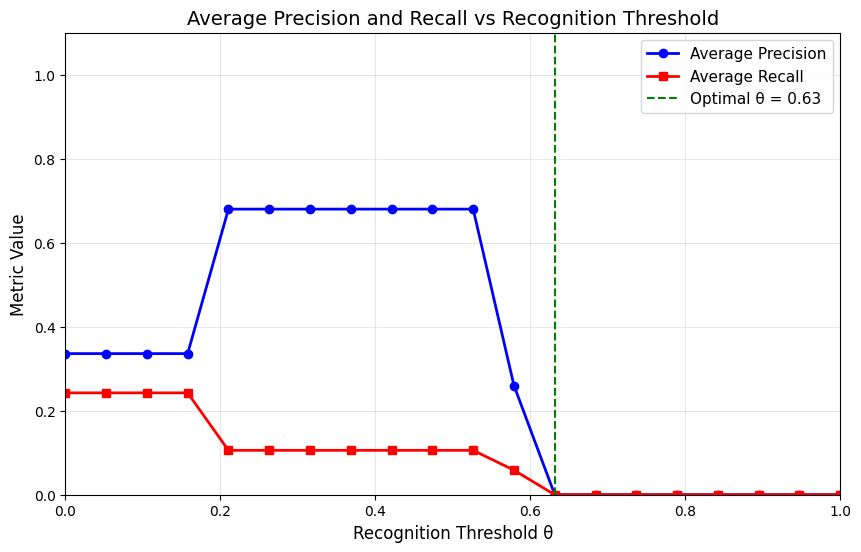


STEP 12: Displaying global event log...

GLOBAL EVENT LOG (Last 15 events)
Paper Eq. 7: E' = ∪ E^u

#     Timestamp            Bldg   Zone         Occupant                  Prob     Visitor 
----------------------------------------------------------------------------------------------------
1     09:47:00             B0     z2_b0        Arnold Schwarzenegger     0.565    No      
2     09:49:00             B1     z4_b1        Gerhard Schroeder         0.600    No      
3     09:54:00             B2     z2_b2        Guillermo Coria           0.555    No      
4     10:06:00             B3     z1_b3        Junichiro Koizumi         0.578    No      
5     10:09:00             B0     z3_b0        Arnold Schwarzenegger     0.572    No      
6     10:14:00             B3     z2_b3        Junichiro Koizumi         0.548    No      
7     10:23:00             B2     z3_b2        Guillermo Coria           0.584    No      
8     10:37:00             B1     zT_b1        Gerhard Schroeder      

In [33]:
# ============================================================================
# MAIN SIMULATION
# Puts everything together
# ============================================================================

def main():
    """
    Main simulation entry point

    Workflow:
    1. Load data and generate encodings
    2. Create buildings (BSTS instances)
    3. Initialize DSTS coordinator
    4. Display registered occupants (YOUR REQUEST)
    5. Simulate occupant movement
    6. Display state tables
    7. Display occupant tracks
    8. Evaluate precision/recall
    9. Generate visualizations
    """

    print("\n" + "=" * 80)
    print("DSTS SIMULATION - Multi-Building Occupant Tracking")
    print("Based on: Mohan & Menon, IET Computer Vision 2020")
    print("=" * 80 + "\n")

    # ========================================================================
    # STEP 1: Load data and generate encodings
    # ========================================================================
    print("STEP 1: Loading LFW dataset and generating face encodings...")
    lfw_data, selected_people, encodings_database = load_lfw_data_and_generate_encodings(
        min_faces_per_person=IMAGES_PER_PERSON
    )

    # ========================================================================
    # STEP 2: Partition occupants into buildings
    # ========================================================================
    print("\nSTEP 2: Partitioning occupants into buildings...")
    building_assignments = partition_occupants_into_buildings(selected_people)

    # ========================================================================
    # STEP 3: Create central directory
    # ========================================================================
    print("\nSTEP 3: Creating central directory...")
    central_directory = create_central_directory(building_assignments, encodings_database)

    # ========================================================================
    # STEP 4: Display registered occupants (YOUR REQUEST)
    # ========================================================================
    print("\n")
    display_registered_occupants(building_assignments, central_directory)
    input("Press Enter to continue...")

    # ========================================================================
    # STEP 5: Create BSTS instances for each building
    # ========================================================================
    print("\nSTEP 5: Creating Building-Specific State Transition Systems...")
    buildings = {}
    for building_id, occupants in building_assignments.items():
        zones = BUILDING_ZONE_CONFIGS[building_id]
        bsts = BSTS(building_id, zones, occupants)
        buildings[building_id] = bsts
        print(f"  Created BSTS for Building {building_id}: {len(zones)} zones, "
              f"{len(occupants)} registered occupants")

    # ========================================================================
    # STEP 6: Initialize DSTS coordinator
    # ========================================================================
    print("\nSTEP 6: Initializing DSTS coordinator...")
    dsts = DSTS()

    for building_id, bsts in buildings.items():
        dsts.register_building(bsts)

    dsts.set_central_directory(central_directory)

    # Create recognition engine
    recognition_engine = FaceRecognitionEngine(encodings_database)
    dsts.set_recognition_engine(recognition_engine)

    print("DSTS initialized successfully!")

    # ========================================================================
    # STEP 7: Simulate occupant movement
    # ========================================================================
    print("\nSTEP 7: Simulating occupant movement...")
    event_history = simulate_occupant_movement(
        dsts=dsts,
        lfw_data=lfw_data,
        encodings_database=encodings_database,
        num_events=50,  # Adjust as needed
        include_visitor_events=True
    )

    # ========================================================================
    # STEP 8: Display state tables
    # ========================================================================
    print("\nSTEP 8: Displaying current state tables...")
    for building_id in range(NUM_BUILDINGS):
        display_state_tables(dsts, building_id, theta=0.82)
        if building_id < NUM_BUILDINGS - 1:
            print("\n" + "." * 100 + "\n")

    input("\nPress Enter to continue to tracking results...")

    # ========================================================================
    # STEP 9: Display occupant tracks
    # ========================================================================
    print("\nSTEP 9: Displaying occupant movement tracks...")

    # Show tracks for first 3 active occupants
    active_occupants = []
    for building_id, building in dsts.buildings.items():
        occupants_list = list(building.registered_occupants)[:2]
        active_occupants.extend(occupants_list)

    for occupant_id in active_occupants[:3]:
        display_occupant_track(dsts, occupant_id)

    input("\nPress Enter to continue to performance evaluation...")

    # ========================================================================
    # STEP 10: Evaluate precision and recall
    # ========================================================================
    print("\nSTEP 10: Evaluating precision and recall...")
    evaluator = PerformanceEvaluator(dsts)

    # Define threshold values to test (Paper Table 6)
    theta_values = [0.0, 0.1, 0.3, 0.5, 0.82, 0.9, 1.0]

    # Compute average metrics
    metrics = evaluator.evaluate_average_metrics(event_history, theta_values)

    # Display results
    display_precision_recall_table(metrics,
                                   title="AVERAGE PRECISION AND RECALL (Paper Table 6)")

    # Find optimal threshold
    optimal_theta = evaluator.find_optimal_threshold(event_history)
    print(f"Optimal recognition threshold: θ = {optimal_theta:.3f}")
    print(f"(Paper reports θ = 0.82 for their experimental setup)\n")

    # ========================================================================
    # STEP 11: Plot precision-recall curve
    # ========================================================================
    print("\nSTEP 11: Generating precision-recall curve (Paper Fig. 5)...")

    # Compute metrics for more theta values for smooth curve
    theta_range = np.linspace(0.0, 1.0, 20)
    detailed_metrics = evaluator.evaluate_average_metrics(
        event_history, theta_range.tolist()
    )

    plot_precision_recall_curve(detailed_metrics, save_path='precision_recall_curve.png')

    # ========================================================================
    # STEP 12: Display global event log
    # ========================================================================
    print("\nSTEP 12: Displaying global event log...")
    display_event_log(dsts, num_events=15)

    # ========================================================================
    # STEP 13: Query examples
    # ========================================================================
    print("\nSTEP 13: Example location queries...")
    print("\n" + "=" * 80)
    print("LOCATION QUERIES (θ = 0.82)")
    print("=" * 80 + "\n")

    for occupant_id in active_occupants[:5]:
        result = dsts.query_occupant_location(occupant_id, theta=0.82)
        if result:
            building_id, zone_id, prob = result
            print(f"{occupant_id:<30} → Building {building_id}, {zone_id} "
                  f"(p={prob:.3f})")
        else:
            print(f"{occupant_id:<30} → Location unknown (p < θ)")

    print("\n" + "=" * 80)
    print("SIMULATION COMPLETE")
    print("=" * 80 + "\n")

    # Summary statistics
    print("SUMMARY STATISTICS:")
    print(f"  Total buildings: {len(dsts.buildings)}")
    print(f"  Total registered occupants: {len(central_directory)}")
    print(f"  Total events simulated: {len(dsts.global_event_log)}")
    print(f"  Simulation time span: {dsts.current_time.strftime('%H:%M:%S')}")

    # Count visitors
    total_visitors = 0
    for building in dsts.buildings.values():
        total_visitors += len(building.visitor_table.get_all_occupants())
    print(f"  Current visitors across all buildings: {total_visitors}")

    print("\n")


if __name__ == "__main__":
    main()